# Байесовская оценка игр Steam

В этом ноутбуке строится более устойчивый рейтинг игр. Простая доля положительных отзывов плохо работает для игр с маленьким числом отзывов: 98% при 100 отзывах и 98% при миллионе отзывов не одинаково надежны. оценка байеса подтягивает игры с меньшей базой отзывов к среднему уровню датасета.

## Импорты и настройки

Здесь подключаются библиотеки, пути проекта и параметры фильтрации. Мы ограничиваем годы релиза периодом 2010-2025 и оставляем только игры с достаточным количеством отзывов, чтобы случайные маленькие игры не занимали верх рейтинга.

In [12]:
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))


import json

from IPython.display import Image, display
import matplotlib.pyplot as plt
import pandas as pd

from project_paths import (
    BAYESIAN_TOP_ALL_TIME_PLOT_PATH,
    BAYESIAN_TOP_BY_YEAR_PLOT_PATH,
    STEAM_GAMES_DATASET_CSV_PATH,
)

DATASET_PATH = STEAM_GAMES_DATASET_CSV_PATH

REVIEW_QUANTILE = 0.25
MIN_TOTAL_REVIEWS = 500
MIN_YEAR = 2010
MAX_YEAR = 2025
TOP_ALL_TIME_N = 10
TOP_BY_YEAR_N = 3

## Загрузка датасета

Берем финальный CSV после парсинга metadata и reviews. На этом шаге данные еще не фильтруются: нам важно сначала увидеть исходный размер датасета.

In [13]:
df = pd.read_csv(DATASET_PATH)
print(f"Загружено строк: {len(df)}")
df.head()

Загружено строк: 38372


,appid,name,is_free,developers,publishers,price_final,price_currency,windows,mac,linux,categories,genres,release_date,review_score_desc,total_positive,total_negative
0,10,Counter-Strike,False,"[""Valve""]","[""Valve""]",999.0,USD,True,True,True,"[""Multi-player"", ""PvP"", ""Online PvP"", ""Shared/...","[""Action""]",2000-11-01,Overwhelmingly Positive,253209.0,6724.0
1,20,Team Fortress Classic,False,"[""Valve""]","[""Valve""]",499.0,USD,True,True,True,"[""Multi-player"", ""PvP"", ""Online PvP"", ""Shared/...","[""Action""]",1999-04-01,Very Positive,7984.0,1183.0
2,30,Day of Defeat,False,"[""Valve""]","[""Valve""]",499.0,USD,True,True,True,"[""Multi-player"", ""Camera Comfort"", ""Color Alte...","[""Action""]",2003-05-01,Very Positive,6595.0,712.0
3,40,Deathmatch Classic,False,"[""Valve""]","[""Valve""]",499.0,USD,True,True,True,"[""Multi-player"", ""PvP"", ""Online PvP"", ""Shared/...","[""Action""]",2001-06-01,Very Positive,2732.0,554.0
4,50,Half-Life: Opposing Force,False,"[""Gearbox Software""]","[""Valve""]",499.0,USD,True,True,True,"[""Single-player"", ""Multi-player"", ""Custom Volu...","[""Action""]",1999-11-01,Overwhelmingly Positive,26953.0,1314.0


## Функция расчета оценка байеса

Функция оставляет строки с review-полями, приводит отзывы к числам, считает `total_reviews`, затем применяет два фильтра: абсолютный минимум отзывов и нижний квартиль по числу отзывов. После этого рассчитываются средняя доля положительных отзывов `m`, медианное число отзывов `C` и итоговая байесовская оценка.

In [14]:
def prepare_bayesian_scores(df: pd.DataFrame) -> tuple[pd.DataFrame, float, float, float]:
    # расчет оценки
    # оставляем только строки, где есть данные по отзывам
    df = df.dropna(subset=["total_positive", "total_negative"]).copy()

    # приводим отзывы к числам на случай строковых значений в csv
    df["total_positive"] = pd.to_numeric(df["total_positive"], errors="coerce")
    df["total_negative"] = pd.to_numeric(df["total_negative"], errors="coerce")
    df = df.dropna(subset=["total_positive", "total_negative"]).copy()

    # считаем общий объем отзывов и убираем слишком маленькие игры
    df["total_reviews"] = df["total_positive"] + df["total_negative"]
    df = df[df["total_reviews"] >= MIN_TOTAL_REVIEWS].copy()

    # после абсолютного порога берем верхние 75% игр по объему отзывов
    min_reviews = df["total_reviews"].quantile(REVIEW_QUANTILE)
    df = df[df["total_reviews"] >= min_reviews].copy()

    # обычная доля положительных отзывов без байесовской поправки
    df["positive_ratio"] = df["total_positive"] / df["total_reviews"]

    # m — средняя доля положительных, c — типичный объем отзывов
    m = df["positive_ratio"].mean()
    c = df["total_reviews"].median()

    # формула байеса игры с малым числом отзывов тянутся к среднему m
    df["bayesian_score"] = (df["total_positive"] + c * m) / (df["total_reviews"] + c)

    return df, m, c, min_reviews

## Расчет оценки

Здесь создается рабочий DataFrame с новой колонкой `bayesian_score`. Параметр `m` показывает средний уровень положительных отзывов в отфильтрованной выборке, а `C` задает силу сглаживания через медианное число отзывов.

In [15]:
scored_df, m, c, min_reviews = prepare_bayesian_scores(df)

print(f"Строк после фильтрации отзывов: {len(scored_df)}")
print(f"Абсолютный минимум отзывов: {MIN_TOTAL_REVIEWS}")
print(f"Порог по 25 квартилю отзывов: {min_reviews:.0f}")
print(f"m, средняя доля положительных отзывов: {m:.4f}")
print(f"C, медианное число отзывов: {c:.0f}")
scored_df[["name", "total_positive", "total_negative", "total_reviews", "positive_ratio", "bayesian_score"]].head()

Строк после фильтрации отзывов: 3197
Абсолютный минимум отзывов: 500
Порог по 25 квартилю отзывов: 896
m, средняя доля положительных отзывов: 0.8226
C, медианное число отзывов: 3333


,name,total_positive,total_negative,total_reviews,positive_ratio,bayesian_score
0,Counter-Strike,253209.0,6724.0,259933.0,0.974132,0.972213
1,Team Fortress Classic,7984.0,1183.0,9167.0,0.870950,0.858053
2,Day of Defeat,6595.0,712.0,7307.0,0.902559,0.877506
3,Deathmatch Classic,2732.0,554.0,3286.0,0.831406,0.826963
4,Half-Life: Opposing Force,26953.0,1314.0,28267.0,0.953515,0.939705


После фильтрации остается 3197 игр: это уже не весь датасет, а только игры с достаточно надежной базой отзывов. Минимальный абсолютный порог равен 500 отзывам, но после отбора верхних 75% по числу отзывов фактический порог стал 896 отзывов. Параметр `C = 3333` означает, что игры с небольшим числом отзывов сильнее подтягиваются к среднему уровню положительных оценок `m = 0.8226`.

## Отбор игр по годам и за все время

Дата релиза переводится в год, после чего оставляется только период 2010-2025. Для общего рейтинга берем топ-10 игр, а для годового графика - топ-3 игры внутри каждого года.

In [16]:
def add_release_year(df: pd.DataFrame) -> pd.DataFrame:
    # год релиза
    df = df.copy()
    # некорректные даты превращаются удаляются
    df["year"] = pd.to_datetime(df["release_date"], errors="coerce").dt.year
    df = df.dropna(subset=["year"]).copy()
    df["year"] = df["year"].astype(int)

    # ограничиваем период
    df = df[(df["year"] >= MIN_YEAR) & (df["year"] <= MAX_YEAR)].copy()

    return df


def get_top_by_year(df: pd.DataFrame) -> pd.DataFrame:
    # топ по годам
    df = add_release_year(df)

    # сортируем внутри каждого года и берем лучшие игры
    return (
        df.sort_values(["year", "bayesian_score"], ascending=[True, False])
        .groupby("year")
        .head(TOP_BY_YEAR_N)
        .reset_index(drop=True)
    )


def get_top_all_time(df: pd.DataFrame) -> pd.DataFrame:
    # топ за все время
    df = add_release_year(df)

    # берем лучшие игры за весь выбранный период
    return (
        df.sort_values("bayesian_score", ascending=False)
        .head(TOP_ALL_TIME_N)
        .reset_index(drop=True)
    )

## Подписи для графиков

Эти функции готовят короткие названия игр, форматируют количество отзывов и добавляют к названию первые жанры. Так график топ-10 за все время показывает игру и ее жанры.

In [17]:
def shorten_name(name: object, max_length: int = 42) -> str:
    # короткое название
    name = str(name)

    if len(name) <= max_length:
        return name

    return f"{name[:max_length - 3]}..."


def parse_genres(genres_str: object) -> list[str]:
    # жанры из json-строки
    try:
        genres = json.loads(genres_str)
    except (json.JSONDecodeError, TypeError):
        return []

    if not isinstance(genres, list):
        return []

    return [str(genre) for genre in genres if genre]


def format_game_with_genres(row: pd.Series) -> str:
    # название и первые жанры
    genres = parse_genres(row.get("genres"))
    game_name = shorten_name(row["name"], max_length=34)

    if not genres:
        return game_name

    return f"{game_name} | {', '.join(genres[:3])}"


def format_reviews(value: float) -> str:
    # формат отзывов
    return f"{int(value):,}".replace(",", " ")

## Топ-10 игр за все время

Сначала смотрим общий рейтинг лучших игр за выбранный период. Рядом с оценка байеса выводится количество отзывов: оно помогает понять, насколько надежна высокая оценка.

In [18]:
top_all_time = get_top_all_time(scored_df)
top_all_time[["name", "release_date", "genres", "bayesian_score", "total_reviews"]]

,name,release_date,genres,bayesian_score,total_reviews
0,Portal 2,2011-04-18,"[""Action"", ""Adventure""]",0.985870,460520.0
1,Stardew Valley,2016-02-26,"[""Indie"", ""RPG"", ""Simulation""]",0.984232,1012164.0
2,Half-Life: Alyx,2020-03-23,"[""Action"", ""Adventure""]",0.977685,104011.0
3,RimWorld,2018-10-17,"[""Indie"", ""Simulation"", ""Strategy""]",0.976708,240624.0
4,Slime Rancher,2017-08-01,"[""Action"", ""Adventure"", ""Indie"", ""Simulation""]",0.976566,153973.0
5,Totally Accurate Battle Simulator,2021-04-01,"[""Indie"", ""Simulation"", ""Strategy""]",0.974796,150468.0
6,OneShot,2016-12-08,"[""Adventure"", ""Casual"", ""Indie""]",0.974782,62981.0
7,Mount & Blade: Warband,2010-03-31,"[""Action"", ""RPG""]",0.974260,171076.0
8,Euro Truck Simulator 2,2012-10-12,"[""Indie"", ""Simulation""]",0.973997,922753.0
9,Terraria,2011-05-16,"[""Action"", ""Adventure"", ""Indie"", ""RPG""]",0.973555,1527555.0


## График топ-10 за все время


Сохранен в C:\Users\User\Desktop\workspaces\SteamAnalytics\SteamParcer\analytics\graphs\bayesian_top_all_time.png


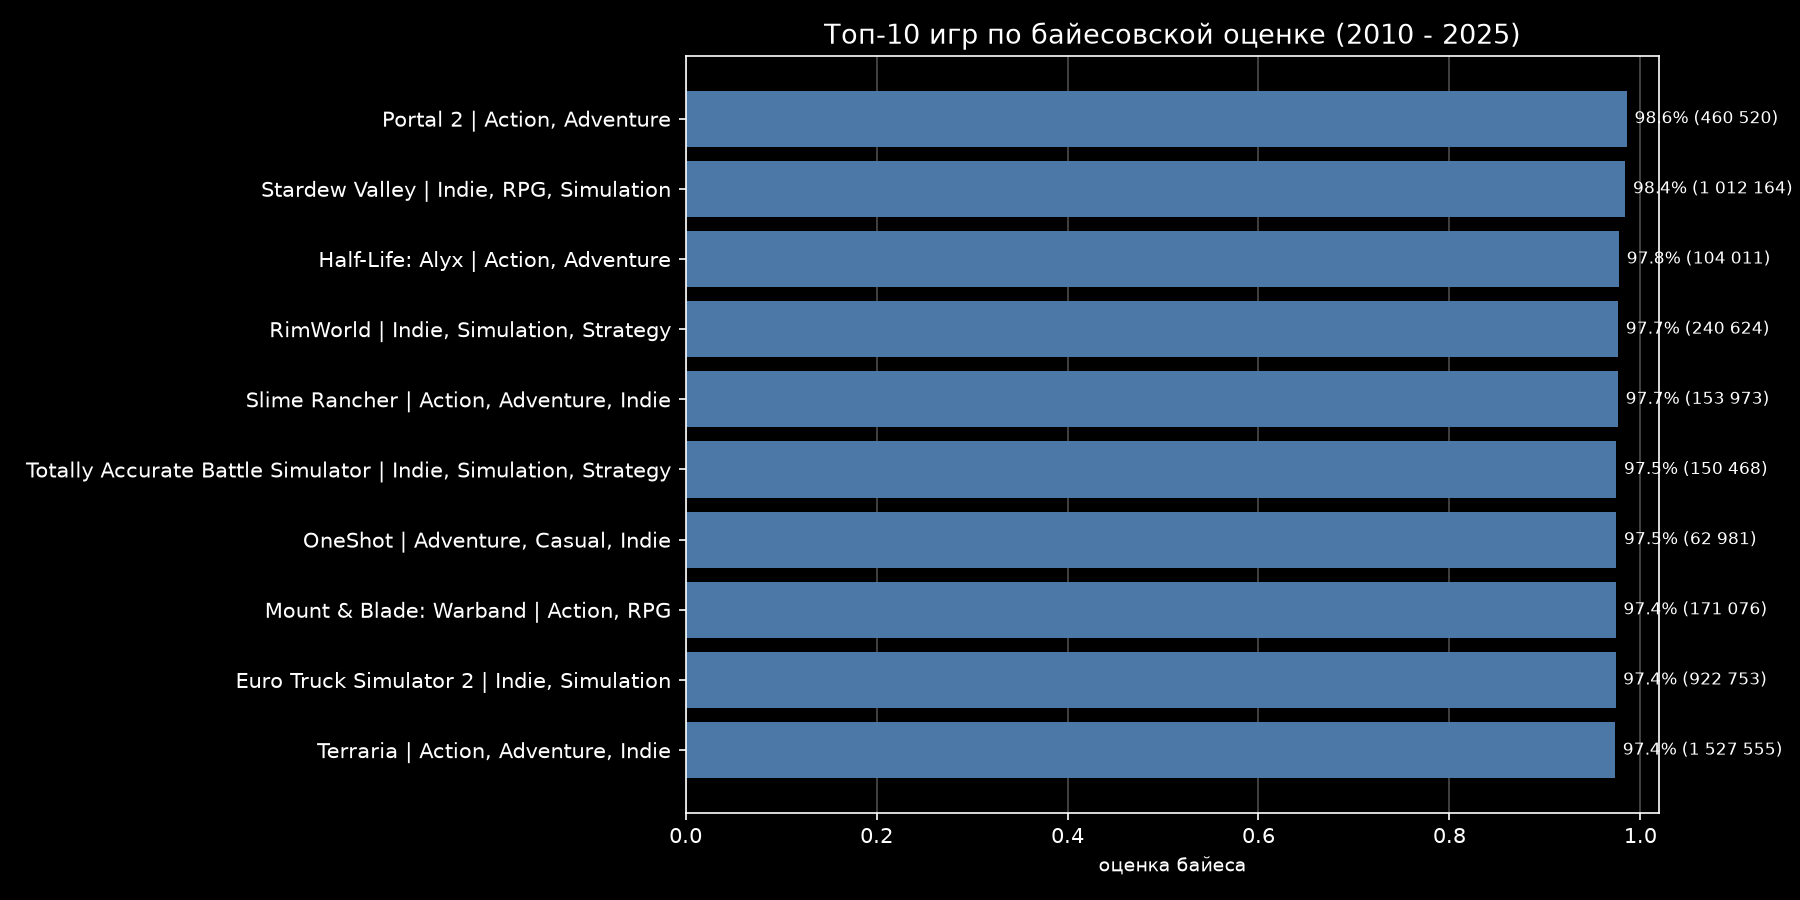

In [19]:
def plot_top_all_time(top_games: pd.DataFrame) -> None:
    # график за все время
    plot_df = top_games.sort_values("bayesian_score", ascending=True)

    labels = [format_game_with_genres(row) for _, row in plot_df.iterrows()]
    values = plot_df["bayesian_score"]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(labels, values, color="#4c78a8", zorder=2)
    ax.set_xlim(0, 1.02)
    ax.grid(axis="x", alpha=0.3, zorder=0)
    ax.set_xlabel("оценка байеса", fontsize=9)
    ax.set_title(f"Топ-10 игр по байесовской оценке ({MIN_YEAR} - {MAX_YEAR})", fontsize=13)

    # рядом с баром пишем score и количество отзывов
    for y, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(
            row["bayesian_score"] + 0.008,
            y,
            f"{row['bayesian_score']:.1%} ({format_reviews(row['total_reviews'])})",
            va="center",
            fontsize=8,
        )

    plt.tight_layout()
    BAYESIAN_TOP_ALL_TIME_PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(BAYESIAN_TOP_ALL_TIME_PLOT_PATH, dpi=150)
    plt.close(fig)
    print(f"Сохранен в {BAYESIAN_TOP_ALL_TIME_PLOT_PATH}")

plot_top_all_time(top_all_time)
display(Image(filename=str(BAYESIAN_TOP_ALL_TIME_PLOT_PATH)))

В общем топе лидируют не случайные малые игры, а проекты с очень большим числом отзывов: например, `Portal 2`, `Stardew Valley` и `Half-Life: Alyx`. Это значит, что байесовская оценка сейчас ведет себя адекватно: высокая позиция требует не только высокой доли положительных отзывов, но и достаточной статистической базы.

## Топ-3 игры в каждом году

Теперь считаем рейтинг отдельно по годам. Такой график полезен, если нужно сравнить лучшие релизы внутри конкретного года.

In [22]:
top_by_year = get_top_by_year(scored_df)
print(f"Строк в годовом топе: {len(top_by_year)}")
top_by_year[["year", "name", "bayesian_score", "total_reviews"]].head(12)

Строк в годовом топе: 48


,year,name,bayesian_score,total_reviews
0,2010,Mount & Blade: Warband,0.974260,171076.0
1,2010,STAR WARS™ Empire at War - Gold Pack,0.965961,42507.0
2,2010,Fallout: New Vegas,0.958197,257975.0
3,2011,Portal 2,0.985870,460520.0
4,2011,Terraria,0.973555,1527555.0
5,2011,Saints Row: The Third,0.950379,69466.0
6,2012,Euro Truck Simulator 2,0.973997,922753.0
7,2012,Dishonored,0.970619,86056.0
8,2012,The Walking Dead,0.967198,79507.0
9,2013,"Papers, Please",0.966940,79134.0


## График топ-3 по годам

В каждом году отображаются три игры с максимальной оценкой байеса. Подписи содержат название игры, процентную оценку и число отзывов.

Plot saved to C:\Users\User\Desktop\workspaces\SteamAnalytics\SteamParcer\analytics\graphs\bayesian_top_by_year.png


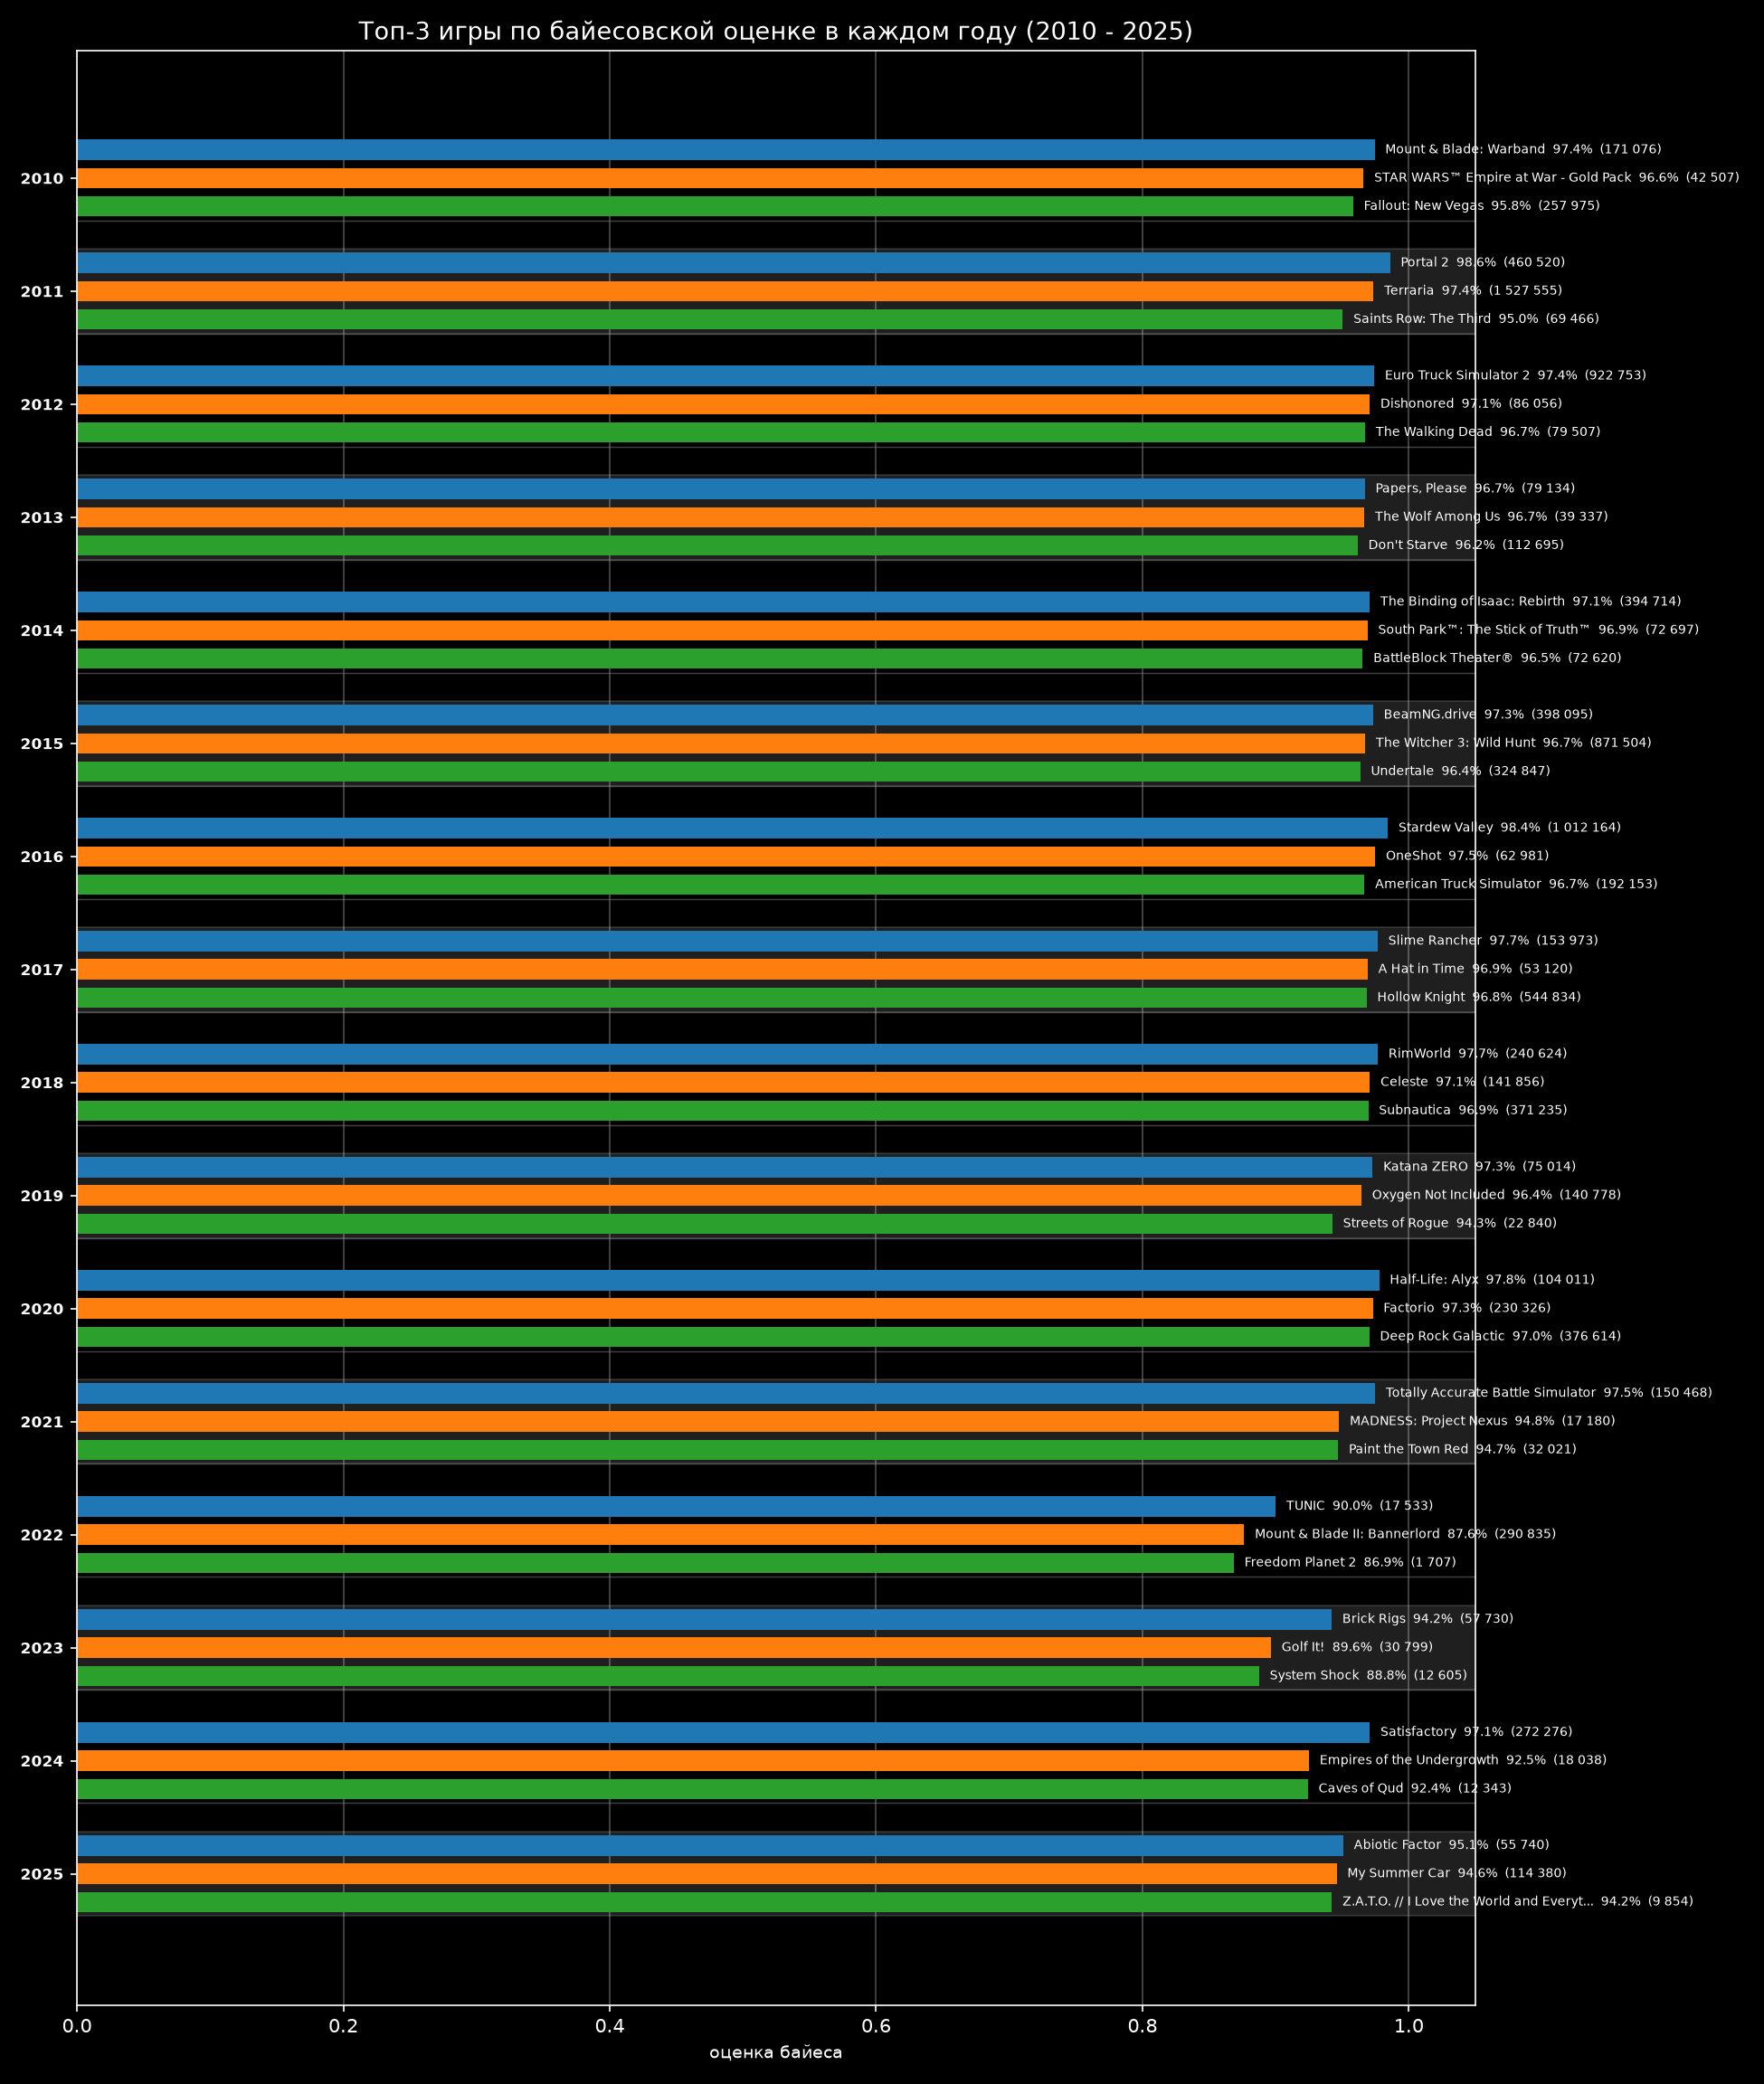

In [21]:
def plot_top_by_year(top_games: pd.DataFrame) -> None:
    # график по годам
    years = sorted(top_games["year"].unique())
    colors = plt.cm.tab10.colors

    # списки нужны, чтобы собрать позиции баров вручную по группам лет
    y_pos = []
    values = []
    labels = []
    bar_colors = []
    year_ticks = []
    year_labels = []
    spans = []
    separators = []

    current_y = 0

    for year_index, year in enumerate(years):
        year_rows = (
            top_games[top_games["year"] == year]
            .sort_values("bayesian_score", ascending=False)
            .head(TOP_BY_YEAR_N)
        )

        if year_rows.empty:
            continue

        start_y = current_y

        # добавляем бары текущего года
        for rank, (_, row) in enumerate(year_rows.iterrows()):
            y_pos.append(current_y)
            values.append(row["bayesian_score"])
            labels.append(
                f"{shorten_name(row['name'])}  "
                f"{row['bayesian_score']:.1%}  "
                f"({format_reviews(row['total_reviews'])})"
            )
            bar_colors.append(colors[rank % len(colors)])
            current_y += 1

        end_y = current_y - 1
        year_ticks.append((start_y + end_y) / 2)
        year_labels.append(str(year))

        # чередуем заливку
        if year_index % 2 == 1:
            spans.append((start_y - 0.5, end_y + 0.5))

        separators.append(end_y + 0.5)
        current_y += 1

    # высота зависит от числа баров, чтобы подписи не налезали друг на друга
    fig_height = max(10, len(y_pos) * 0.32)
    fig, ax = plt.subplots(figsize=(13, fig_height))
    ax.barh(y_pos, values, height=0.72, color=bar_colors, zorder=2)
    ax.set_yticks(year_ticks)
    ax.set_yticklabels(year_labels, fontsize=8, fontweight="bold")
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)
    ax.grid(axis="x", alpha=0.3, zorder=0)
    ax.set_xlabel("оценка байеса", fontsize=9)

    for y, val, label in zip(y_pos, values, labels):
        ax.text(
            val + 0.008,
            y,
            label,
            va="center",
            fontsize=6.5,
        )

    for start, end in spans:
        ax.axhspan(start, end, color="lightgray", alpha=0.15, zorder=0)

    for sep in separators[:-1]:
        ax.axhline(y=sep, color="gray", linewidth=0.7, alpha=0.5)

    ax.set_title(f"Топ-3 игры по байесовской оценке в каждом году ({MIN_YEAR} - {MAX_YEAR})", fontsize=13)
    plt.tight_layout()
    BAYESIAN_TOP_BY_YEAR_PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(BAYESIAN_TOP_BY_YEAR_PLOT_PATH, dpi=150)
    plt.close(fig)
    print(f"Plot saved to {BAYESIAN_TOP_BY_YEAR_PLOT_PATH}")

plot_top_by_year(top_by_year)
display(Image(filename=str(BAYESIAN_TOP_BY_YEAR_PLOT_PATH)))

Годовой топ полезен как дополнение к общему рейтингу: он не дает старым хитам полностью занять весь анализ и показывает сильные релизы внутри каждого года. При чтении этого графика важно помнить, что игры сравниваются только с релизами своего года, поэтому его нельзя напрямую трактовать как общий рейтинг всех игр.